Recovered causal order: [0, 1, 2, 3, 4]
Adjacency (estimated) 
 [[0.   0.   0.   0.   0.  ]
 [0.81 0.   0.   0.   0.  ]
 [0.73 0.46 0.   0.   0.  ]
 [0.47 0.83 0.65 0.   0.  ]
 [0.32 0.5  0.74 0.74 0.  ]]


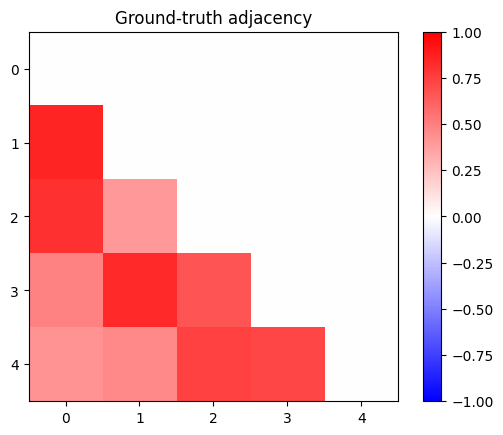

In [1]:
import numpy as np
from lingam import DirectLiNGAM
import matplotlib.pyplot as plt

# --- toy linear DAG generator ---------------------------------
def make_linear_dag(d=5, seed=0):
    rng = np.random.default_rng(seed)
    B = np.tril(rng.uniform(0.4, 0.9, size=(d, d)), k=-1)  # random strictly lower-tri
    n = 1000
    X = rng.standard_normal((n, d)) @ np.linalg.inv(np.eye(d) - B).T
    return X, B

# --- fit baseline HSIC-LiNGAM ---------------------------------
X, B_true = make_linear_dag(d=5)
model = DirectLiNGAM(measure='kernel')    # default HSIC
#model = DirectLiNGAM(measure='pwling')  
model.fit(X)

print("Recovered causal order:", model.causal_order_)
print("Adjacency (estimated) \n", np.round(model.adjacency_matrix_, 2))

# --- quick visual check ---------------------------------------
plt.imshow(B_true, cmap='bwr', vmin=-1, vmax=1)
plt.title("Ground-truth adjacency"), plt.colorbar(); plt.show()


In [2]:
from hgrlingam import HGRDirectLiNGAM, shd
from lingam import DirectLiNGAM          # baseline for comparison

# --- baseline (PW-LingAM) on linear data -----------
pw_lin = DirectLiNGAM(random_state=0).fit(X_lin)

# --- HGR-LiNGAM ------------------------------------
HGRDirectLiNGAM._hgr_calls = 0          # reset the debug counter
hgr_lin = HGRDirectLiNGAM(random_state=0).fit(X_lin)

print("Baseline SHD (linear):", shd(pw_lin.adjacency_matrix_,  B_gt))
print("HGR      SHD (linear):", shd(hgr_lin.adjacency_matrix_, B_gt))
print("HGR calls executed   :", HGRDirectLiNGAM._hgr_calls)   # should be > 0
print("Recovered order      :", hgr_lin.causal_order_)


NameError: name 'X_lin' is not defined

In [37]:
import numpy as np
from maxcorr import indicator

# reusable HGR scorer -------------------------------------------------
_hgr = indicator(semantics='hgr',
                 algorithm='dk',     # double-kernel estimator
                 backend='numpy',
                 # we’ll start with a simple 10-degree polynomial basis
                 # (same on X and residual stack).  You can tune later.
                 kernel_a=5,
                 kernel_b=5)


from maxcorr import indicator
import numpy as np

def hgr_score(x_root, residual_stack, basis=10):
    """
    Double-kernel HGR between x_root (n,) and residual_stack (n×k).
    """
    hgr = indicator(semantics="hgr",
                    algorithm="dk",
                    backend="numpy",
                    kernel_a=basis,
                    kernel_b=basis)
    y = residual_stack.reshape(residual_stack.shape[0], -1)
    return hgr.compute(x_root, y)


In [43]:
# Find all functions in lingam.utils whose name contains "hsic"
helpers = [name for name in dir(lu) if "hsic" in name.lower()]
print("Patching these helpers:", helpers)

for name in helpers:
    setattr(lu, name, lambda x, r, b=10: hgr_score(x, r, basis=b))


Patching these helpers: ['hsic_test_kernel']


In [47]:
model = HGRDirectLiNGAM(basis=10, random_state=0)
model.fit(X)

order = model.causal_order_
shd   = ((model.adjacency_matrix_ != 0) ^ (B_true != 0)).sum()
print("Recovered order:", order)
print("SHD vs truth   :", shd)
print("Recorded scores:", model.hgr_scores_)


Recovered order: [0, 1, 2, 3, 4]
SHD vs truth   : 0
Recorded scores: []
